# 045. Overfitting in NLP and Transfer Learning of pre-trained Glove model

- text classification 이 overfitting 되기 쉬운 주요 원인 중 하나는 training dataset 이 상당히 작고 단어 수가 작기 때문  


- 이러한 작은 dataset 에서 생성된 embedding 역시 over-generalize 된다. 이에 대한 해결책으로 large dataset 의 training 과 이미 만들어 놓은 embedding 의 transfer learning 을 연습한다.  


- dataset 은 kaggle 의 sentiment140 dataset (https://www.kaggle.com/kazanova/sentiment140) 의 clean-up version 이용.
    - twitter api 로 추출된 1,600,000 tweet (233 MB)
    - 0 = negative, 2 = neutral, 4 = positive 로 구분되어  sentiment 분석 사용 가능
    - 다음의 6 field 로 구성
        - 1. target: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)
        - 2. ids: The id of the tweet ( 2087)
        - 3. date: the date of the tweet
        - 4. flag: The query (lyx). If there is no query, then this value is NO_QUERY
        - 5. user: the user that tweeted
        - 6. text: the text of the tweet   
        
        

- embedding 은 pre-trained GloVe (Global Vectors for Word Representation, https://nlp.stanford.edu/projects/glove/) 사용

In [12]:
import tensorflow as tf
tf.__version__

'2.0.0'

In [17]:
import json
import tensorflow as tf
import csv
import random
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

EMBEDDING_DIMS = 100
MAX_LENGTH = 16
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
TRAINING_SIZE = 400000  # Large dataset 사용 (1,600,000 twit 중 25% 사용)
test_portion = .1

corpus = []

### 전처리된 large dataset 사용

- curl -o training_cleaned.csv https://storage.googleapis.com/laurencemoroney-blog.appspot.com/training_cleaned.csv  

- 228 MB 의 sentiment140 dataset


In [18]:
file_path = tf.keras.utils.get_file("traing_cleaned.csv",
                                "https://storage.googleapis.com/laurencemoroney-blog.appspot.com/training_cleaned.csv")

In [19]:
import pandas as pd

#csv_path = "training_cleaned.csv"
df = pd.read_csv(file_path, header=None)
df.head()

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [20]:
df[0].unique()

array([0, 4], dtype=int64)

- column 5 를 text, column 0 를 label 로 사용  
- label 이 0 과 4 이므로 0 이면 0, 4 면 1 로 labeling

In [21]:
for text, label in zip(df.iloc[:, 5], df.iloc[:, 0]):
    list_item = []
    list_item.append(text)
    if label == 0:
        list_item.append(0)
    else:
        list_item.append(1)
    corpus.append((text, label))

In [22]:
print(len(corpus))
corpus[:5]

1600000


[("@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D",
  0),
 ("is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!",
  0),
 ('@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds',
  0),
 ('my whole body feels itchy and like its on fire ', 0),
 ("@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. ",
  0)]

## text, label 분리 및 train, test set 분리

In [23]:
sentences=[]
labels=[]
random.shuffle(corpus)

for i in range(TRAINING_SIZE):
    sentences.append(corpus[i][0])  
    labels.append(corpus[i][1])  

tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)  

word_index = tokenizer.word_index
vocab_size=len(word_index)  

sequences = tokenizer.texts_to_sequences(sentences)  
padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding=padding_type, truncating=trunc_type) 

split = int(test_portion * TRAINING_SIZE)

test_sequences = padded[0:split]  
training_sequences = padded[split:TRAINING_SIZE]  
test_labels = np.array(labels[0:split])
training_labels = np.array(labels[split:TRAINING_SIZE])

In [24]:
print(vocab_size)
print(list(word_index.items())[:20])
print(len(training_sequences))
print(len(test_sequences))
print(len(training_labels))
print(len(test_labels))

266179
[('i', 1), ('to', 2), ('the', 3), ('a', 4), ('my', 5), ('and', 6), ('you', 7), ('is', 8), ('it', 9), ('for', 10), ('in', 11), ('of', 12), ('on', 13), ('me', 14), ('so', 15), ('have', 16), ('that', 17), ('but', 18), ("i'm", 19), ('just', 20)]
360000
40000
360000
40000


## Transfer Learning - GloVe

- GloVe 의 100 dimension version 사용  



- data url
    - curl -o glove.6B.100d.txt https://storage.googleapis.com/laurencemoroney-blog.appspot.com/glove.6B.100d.txt

In [15]:
glove_path = tf.keras.utils.get_file("glove.6B.100d.txt", 
                              "https://storage.googleapis.com/laurencemoroney-blog.appspot.com/glove.6B.100d.txt")

347119616/347116733 [==============================] - 36s 0us/step


### pre-trained 된 GloVe model 의 weight 를 가져옴

- glove.6B.100d.txt 의 각 line 은 word 와 해당 embedding 값의 100 dimension list 로 구성  

```
**of** -0.1529 -0.24279 0.89837 0.16996 0.53516 0.48784 -0.58826 -0.17982 -1.3581 0.42541 0.15377 0.24215 0.13474 0.41193 0.67043 -0.56418 0.42985 -0.012183 -0.11677 0.31781 0.054177 -0.054273 0.35516 -0.30241 0.31434 -0.33846 0.71715 -0.26855 -0.15837 -0.47467 0.051581 -0.33252 0.15003 -0.1299 -0.54617 -0.37843 0.64261 0.82187 -0.080006 0.078479 -0.96976 -0.57741 0.56491 -0.39873 -0.057099 0.19743 0.065706 -0.48092 -0.20125 -0.40834 0.39456 -0.02642 -0.11838 1.012 -0.53171 -2.7474 -0.042981 -0.74849 1.7574 0.59085 0.04885 0.78267 0.38497 0.42097 0.67882 0.10337 0.6328 -0.026595 0.58647 -0.44332 0.33057 -0.12022 -0.55645 0.073611 0.20915 0.43395 -0.012761 0.089874 -1.7991 0.084808 0.77112 0.63105 -0.90685 0.60326 -1.7515 0.18596 -0.50687 -0.70203 0.66578 -0.81304 0.18712 -0.018488 -0.26757 0.727 -0.59363 -0.34839 -0.56094 -0.591 1.0039 0.20664
```

In [25]:
embeddings_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()                 # 각 줄을 읽어와서 word_vector에 저장
        word = values[0]                    # 첫번째 값은 word
        coefs = np.asarray(values[1:], dtype='float32')  # 두번째 element 부터 마지막까지 100 개는 해당 단어의 임베딩 벡터의  값
        embeddings_index[word] = coefs

embeddings_matrix = np.zeros((vocab_size+1, EMBEDDING_DIMS))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embeddings_matrix[i] = embedding_vector

In [26]:
print(embeddings_matrix.shape)
print(embeddings_matrix[1])

(266180, 100)
[-0.046539    0.61966002  0.56647003 -0.46584001 -1.18900001  0.44599
  0.066035    0.31909999  0.14679    -0.22119001  0.79238999  0.29905
  0.16073     0.025324    0.18678001 -0.31000999 -0.28108001  0.60514998
 -1.0654      0.52476001  0.064152    1.03579998 -0.40779001 -0.38011
  0.30801001  0.59964001 -0.26991001 -0.76034999  0.94221997 -0.46919
 -0.18278     0.90652001  0.79671001  0.24824999  0.25713     0.6232
 -0.44768     0.65357     0.76902002 -0.51229    -0.44332999 -0.21867
  0.38370001 -1.14830005 -0.94397998 -0.15062     0.30012    -0.57805997
  0.20175    -1.65910006 -0.079195    0.026423    0.22051001  0.99713999
 -0.57538998 -2.72659993  0.31448001  0.70521998  1.43809998  0.99125999
  0.13976     1.34739995 -1.1753      0.0039503   1.02980006  0.064637
  0.90886998  0.82871997 -0.47003001 -0.10575     0.5916     -0.42210001
  0.57331002 -0.54114002  0.10768     0.39783999 -0.048744    0.064596
 -0.61436999 -0.28600001  0.50669998 -0.49757999 -0.81569999

### transfer learning

- Embedding layer 의 weights 에 glove.6B.100d.txt 에서 읽어드린 weight load

- trainable=False 로 weight 고정

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size+1, EMBEDDING_DIMS, input_length=MAX_LENGTH, 
                                                      weights=[embeddings_matrix], trainable=False),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy']) 
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 16, 100)           26653900  
_________________________________________________________________
bidirectional (Bidirectional (None, 16, 128)           84480     
_________________________________________________________________
bidirectional_1 (Bidirection (None, 64)                41216     
_________________________________________________________________
dense (Dense)                (None, 64)                4160      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 65        
Total params: 26,783,821
Trainable params: 129,921
Non-trainable params: 26,653,900
_________________________________________________________________


In [15]:
import time

s = time.time()
num_epochs = 10
history = model.fit(training_sequences, training_labels, epochs=num_epochs, 
                                    validation_data=(test_sequences, test_labels), verbose=1)

e = time.time()
print("Training Complete, running time : {:.2} seconds".format((e-s)))

Epoch 1/10
11250/11250 [==============================] - 96s 9ms/step - loss: -122233.5234 - accuracy: 8.6111e-05 - val_loss: -348136.9062 - val_accuracy: 0.0047
Epoch 2/10
11250/11250 [==============================] - 95s 8ms/step - loss: -776217.9375 - accuracy: 0.0493 - val_loss: -1283127.6250 - val_accuracy: 0.0394
Epoch 3/10
11250/11250 [==============================] - 94s 8ms/step - loss: -2030077.3750 - accuracy: 0.0810 - val_loss: -2839413.5000 - val_accuracy: 0.0966
Epoch 4/10
11250/11250 [==============================] - 95s 8ms/step - loss: -3866153.2500 - accuracy: 0.0899 - val_loss: -4965154.5000 - val_accuracy: 0.0836
Epoch 5/10
11250/11250 [==============================] - 94s 8ms/step - loss: -6325336.5000 - accuracy: 0.1018 - val_loss: -7706135.0000 - val_accuracy: 0.0918
Epoch 6/10
11250/11250 [==============================] - 94s 8ms/step - loss: -9374896.0000 - accuracy: 0.1102 - val_loss: -11072267.0000 - val_accuracy: 0.1111
Epoch 7/10
11250/11250 [========

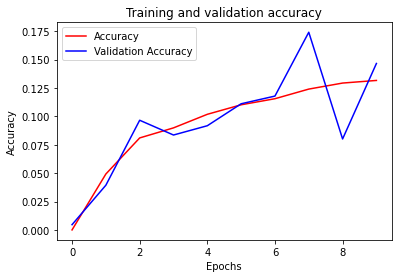

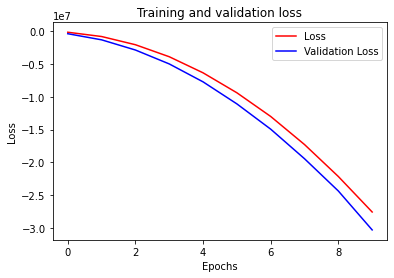

In [16]:
import matplotlib.image  as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc)) 

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Accuracy", "Validation Accuracy"])

plt.figure()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.title('Training and validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Validation Loss"])